 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...


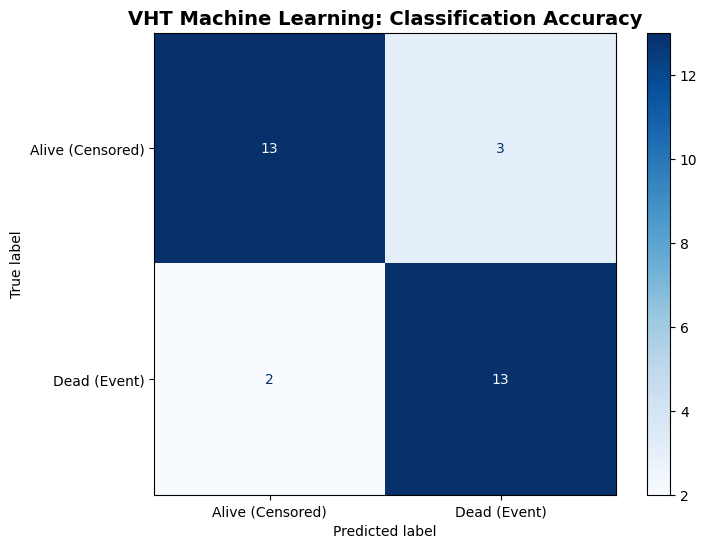

 VHT Matrix Complete: 46 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Multiple surgeries', 'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression'],
      dtype='object')


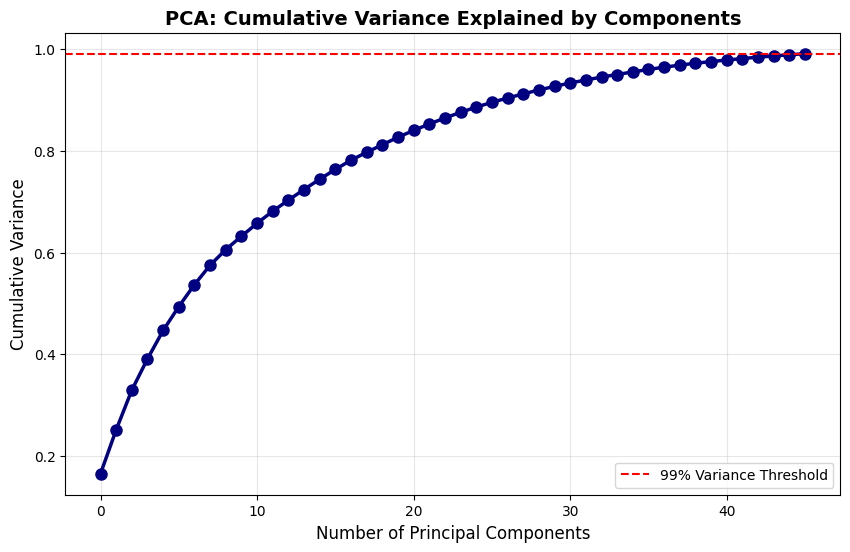

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_16755/3844223011.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')


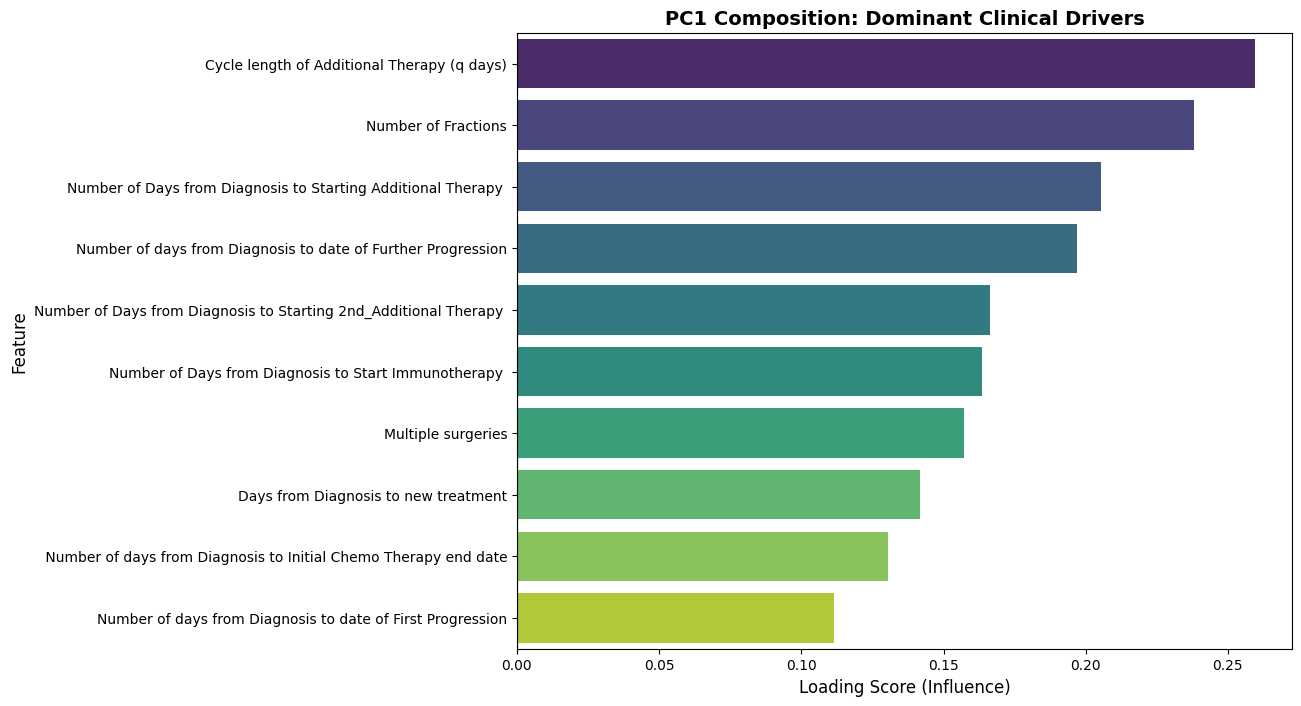

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -340.22
         time fit was run = 2026-05-25 12:00:30 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1       -0.20      0.82      0.04           -0.27           -0.13                0.77                0.88
PC2       -0.20      0.82      0.06           -0.31           -0.09                0.73                0.92
PC3       -0.07      0.93      0.05           -0.16            0.03                0.85                1.03
PC4        0.01      1.01      0.06           -0.11            0.13                0.89                1.14
PC5        0.06      1.06      0.05           -0.05            0.16                0.95                1.18
PC6        0.08      1.08      0.07           -0.06            0.22                0.94                1.25
PC7        0.07      1.08      0.06           -0.05            0.20                0.95                1.22
PC8        0.11      1.12      0.07           -0.02            0.24                0.98                1.27
PC9       -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
PC10       0.05      1.06      0.10           -0.14            0.25                0.87                1.28
PC11       0.01      1.01      0.08           -0.16            0.17                0.85                1.19
PC12       0.14      1.15      0.10           -0.05            0.34                0.95                1.40
PC13      -0.01      0.99      0.09           -0.19            0.17                0.83                1.19
PC14      -0.08      0.92      0.11           -0.29            0.13                0.75                1.14
PC15      -0.29      0.75      0.11           -0.51           -0.07                0.60                0.93
PC16      -0.02      0.98      0.10           -0.22            0.17                0.80                1.19
PC17       0.02      1.02      0.11           -0.20            0.24                0.82                1.27
PC18       0.10      1.10      0.12           -0.13            0.32                0.88                1.38
PC19       0.25      1.28      0.12            0.02            0.48                1.02                1.62
PC20       0.10      1.10      0.13           -0.16            0.35                0.85                1.42
PC21       0.09      1.09      0.11           -0.14            0.31                0.87                1.37
PC22       0.34      1.40      0.14            0.05            0.62                1.05                1.86
PC23      -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
PC24       0.17      1.19      0.15           -0.12            0.46                0.89                1.58
PC25      -0.21      0.81      0.17           -0.54            0.13                0.58                1.14
PC26       0.01      1.01      0.14           -0.27            0.29                0.76                1.33
PC27      -0.01      0.99      0.16           -0.32            0.30                0.72                1.35
PC28      -0.03      0.97      0.17           -0.35            0.29                0.70                1.34
PC29      -0.09      0.91      0.16           -0.42            0.23                0.66                1.26
PC30       0.12      1.13      0.16           -0.19            0.43                0.83                1.54
PC31      -0.51      0.60      0.20           -0.90           -0.12                0.41                0.88
PC32       0

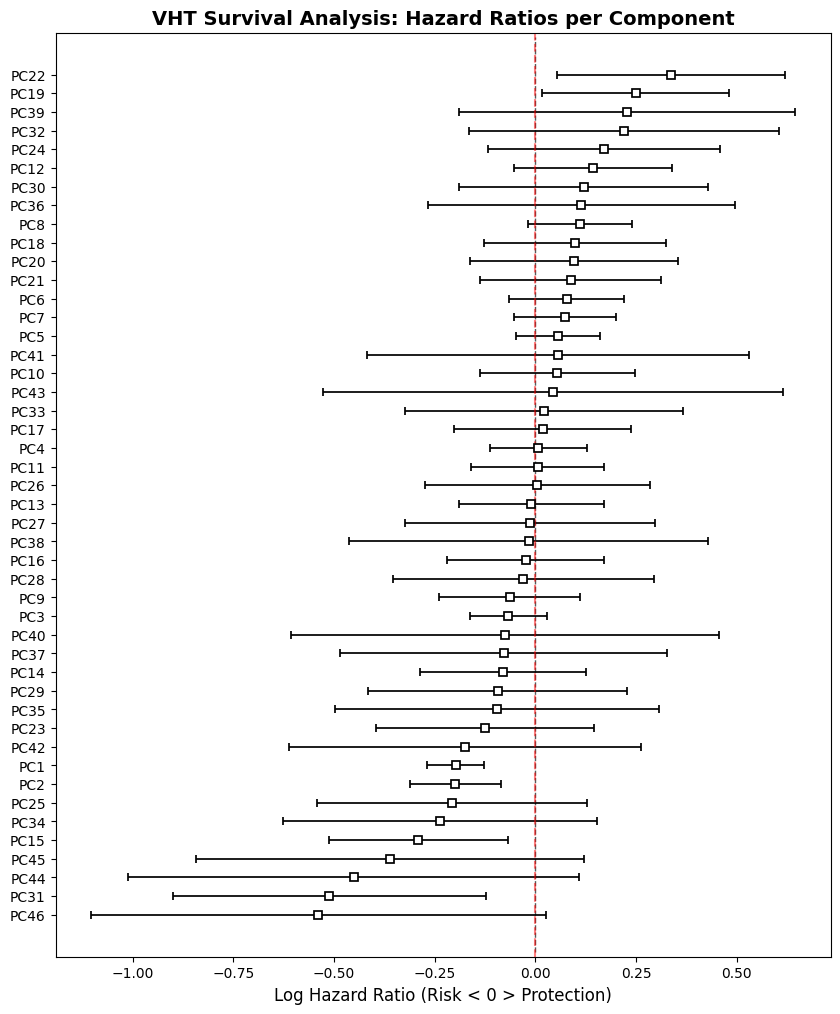

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION (Refined)
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            # Helper to pull the i-th scan in the sequence safely
            def get_val(key): 
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
    
    patient_objects[pid] = obj


# ======================================================================================
# 3. MERGING & CLEANING FOR ML
# ======================================================================================
df_clinical = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
df_clinical['PID_Clean'] = df_clinical['Patient ID'].astype(str).str.split('-').str[0]

# Combine Baseline Clinical + Engineered Kinetic Rates
#df_vht = pd.merge(df_clinical, df_kinetics, on='PID_Clean', how='inner')
df_vht = df_clinical

# Identify targets and drop metadata
targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + ['Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression',             # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Type of 2nd Progression',         # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',  # Time variable
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',  # Time variable
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',  # Time variable
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',  # Time variable
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',  # Time variable
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '   # Time variable
]
X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns])

# Standard Preprocessing
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)

# Prepare y for the split to ensure we reference the actual data, not the name list
y_labels = df_vht[targets[0]].astype(int)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_smote, y_train_smote)

# We use y_test (actual values) instead of targets (list of names)
y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# Plotting fix: disp.plot creates its own axis, we just need to set the title after
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()

# ======================================================================================
# 4. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_pca.shape[1]} components explain 99% variance.")

# Show top drivers of PC1 (Now includes Velocities!)
pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(10).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# ======================================================================================
# 5. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_cox_pca['duration'] = df_vht['Number of days from Diagnosis to death (Days)'].fillna(df_vht['Time to First Progression (Days)']).fillna(1).values
df_cox_pca['event'] = df_vht['Overall Survival (Death)'].astype(int).values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_pca[df_cox_pca['duration'] > 0], duration_col='duration', event_col='event')
cph.print_summary()

# D. COX HAZARD RATIO FOREST PLOT
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()



---

## Technical Methodology: Multi-Scale Clinical-Radiomic Feature Engineering and Survival-Classification Modeling

This script establishes an end-to-end computational pipeline designed to process raw longitudinal medical imaging metadata alongside matched clinical records. The final objective is to train predictive machine learning models to forecast clinical outcomes for high-grade glioma patients within a Virtual Health Twin (VHT) paradigm.

The workflow is broken down into four core architectural layers:

### 1. Multi-Modal Hierarchical Data Ingestion

The pipeline initializes by ingesting spreadsheet-based radiomic abstractions spanning **four structural tumor sub-regions** (Necrotic Core, Peritumoral Edema, Enhancing Border, and Resection Cavity) across multiple sequential imaging timepoints ($T_1 \dots T_n$).

* **Volumetric and Radiomic Parsing:** For each distinct tissue sub-region, the script extracts structural statistics including raw voxel counts, absolute volume dimensions ($mm^3$), and multi-parametric MRI signal intensities (Mean and Standard Deviation across T1-weighted contrast-enhanced, T1-weighted non-contrast, T2-weighted, and Fluid-Attenuated Inversion Recovery [FLAIR] sequences).
* **Robust Positional Indexing:** By utilizing dynamic multi-sheet loops (`pd.ExcelFile`) combined with rigid integer column slicing (`columns[3]` through `columns[12]`), the ingestion block remains fully immune to column label changes or whitespace variations across Excel sequences.
* **Unified Object Relational Mapping:** To bypass row shifting and variable shadowing risks, data is consolidated into an integrated dictionary pattern (`patient_objects`). Each validated patient folder discovered on disk (`patient_ids`) acts as a master key pointing to synchronized arrays of local NIfTI image path lists, multi-sequence spreadsheet sequences, and baseline clinical parameters. An index-bound guard function (`get_val`) prevents sequence out-of-bounds errors by handling missing tracking scans via zero-value fallbacks.

### 2. High-Dimensional Dimensionality Reduction (PCA Space)

To prepare the baseline clinical covariates for algorithmic classification and survival fitting, the script enforces strict feature conditioning directly on the comprehensive data matrix (`df_vht`):

* **Exclusionary Leakage Filtering:** To maintain strict validation integrity, all post-progression, future endpoint identifiers, and secondary recurrence markers are removed. The script purges target features (`Overall Survival (Death)`, `Number of days from Diagnosis to death (Days)`) alongside intermediate timelines (`Time to First Progression (Days)`, `Progression`, and individual `Timepoint_1` to `Timepoint_6` day counts) to construct a pure predictive baseline workspace (`X_raw`).
* **Categorical Encoding & Imputation:** Arbitrary qualitative clinical variables (e.g., nominal treatment classifications) are mapped to numeric spaces using nominal `LabelEncoder` methods, followed by zero-value imputation (`.fillna(0)`) to handle missing data fields uniformly.
* **Covariate Normalization:** To prevent variables with large absolute scales from dominating the model optimization, features are mapped to a standardized Gaussian space ($\mu=0, \sigma=1$) via z-score transformations using `StandardScaler`.
* **Orthogonal Decomposition:** A Principal Component Analysis (PCA) layer is implemented to project the normalized feature matrix into an orthogonal subspace. The component boundary is dynamically constrained to retain **99% of the total dataset variance** (`n_components=0.99`), transforming highly collinear raw features into a minimized set of uncorrelated principal components (`X_pca`).

### 3. Class-Balanced Machine Learning Classification

The script uses an ensemble classification layer to predict the primary binary endpoint: overall patient mortality (`Overall Survival (Death)`).

* **Stratified Validation Split:** Data is partitioned into a training set ($85\%$) and an independent validation subset ($15\%$) using `train_test_split`. This execution incorporates a `stratify` argument to ensure that the baseline ratio of living (censored) to deceased (event) cases remains perfectly balanced between the splits.
* **Synthetic Minority Over-sampling Technique (SMOTE):** To counter severe class imbalances typical of clinical cohorts, SMOTE is applied exclusively to the training vectors (`X_train_pca`, `y_train`) to synthesize artificial minority class entries along feature space vectors, preventing model bias toward the dominant class.
* **Gradient Boosting Ensemble Architecture:** A `GradientBoostingClassifier` ($M=150$ estimators, $\text{Learning Rate}=0.1$, $\text{max\_depth}=4$) is calibrated against the balanced training space. The predictive boundaries are evaluated against the isolated test split using a standardized binary confusion matrix (`ConfusionMatrixDisplay`), detailing classification bounds across `Alive (Censored)` and `Dead (Event)` states.

### 4. Semi-Parametric Survival Analysis (Cox Proportional Hazards)

To model time-to-event dynamics alongside binary outcomes, the pipeline transitions the orthogonal principal components into a semi-parametric regression layout.

* **Survival Timeline Reconciliation:** A dedicated survival dataframe (`df_cox_pca`) is constructed by attaching tracking metrics directly to the components. The timeline variable (`duration`) is dynamically mapped using known days from diagnosis to death. For censored patients, it handles missing records by gracefully falling back onto documented times to first disease progression, ensuring no negative or null timelines enter the fitter.
* **L2-Regularized Cox Regression:** A `CoxPHFitter` model is configured with an explicit ridge penalizer coefficient ($\text{penalizer}=0.1$) to stabilize coefficients against high variance within the principal components. The model fits log-hazard ratios across the components, calculating risk profiles which are subsequently rendered as an analytical Forest Plot to isolate which multi-scale principal component drivers present statistical indicators of high risk versus long-term survivability.

In [2]:
import nibabel as nib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

# ======================================================================================
# 1. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

   # Inside the loop: for pid in patient_ids:
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    # ADJUSTMENT: Filter for longitudinal data (2+ timepoints)
    if len(tps) >= 2:
        obj = {
            'Patient_ID': pid, 
            'clinical': clinical_data.get(clean_id, {}), 
            'timepoints': tps,
            'images': {}, 'volumes': {}, 'voxels': {},
            't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
            't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
        }

        for i, tp in enumerate(tps):
            obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
            for l_name in m_dict['vol'].keys():
                # Helper to pull the i-th scan in the sequence safely
                def get_val(key): 
                    seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                    # Safety check: ensure sequence length matches timepoint index
                    return seq[i] if i < len(seq) else 0

                obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
                obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
                obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
                obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
                obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
                obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
                obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
                obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
                obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
                obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
        
        patient_objects[pid] = obj



 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...




---

## Technical Methodology: Longitudinal Multimodal Data Parsing and Virtual Twin Object Ingestion

This foundational computational module establishes the data ingestion, extraction, and object-oriented integration architecture for the multi-scale **Virtual Human Twin (VHT)** platform. The primary objective of this module is to reconstruct patient-linked, multi-parametric, longitudinal radiomic histories by harmonizing unstructured neuro-imaging file directories with tabular clinical and segmentation metadata.

The data processing workflow is mathematically and structurally divided into three distinct operations:

```
[Tabular Extraction]   --->  [Cohort Filtering]  --->  [VHT Object Generation]
(Spreadsheet Sheets)        (Length Anchor Filter)      (Longitudinal Chronology)

```

---

### Phase 1: High-Dimensional Spreadsheet Extraction and Radiomic Sequencing

To prevent variable shadowing and memory leakage across long compilation loops, a centralized, multi-keyed master container ($\mathbf{M}_{\text{dict}}$) is initialized. The software leverages libraries including `nibabel` for physical spatial calculations alongside native automated parsers to process a multi-sheet spreadsheet containing multi-parametric radiomic signatures extracted from distinct anatomical tumor sub-regions ($\text{ROI} \in \{\text{Necrotic}, \text{Edema}, \text{Enhancing}, \text{Resection}\}$):

$$\mathbf{M}_{\text{dict}} = \{k: \{\text{ROI}: \{\text{PID}: [x_1, x_2, \dots, x_t]\}\}\}$$

where $k$ corresponds to specific structural and signal-intensity metrics:

* **Macrostructural:** Voxel counts (`vox`) and absolute volumes (`vol`).
* **Microstructural Intensity:** Mean sequence values (`t1cm`, `t1nm`, `t2fm`, `t2wm`).
* **Microstructural Heterogeneity:** Standard deviations (`t1cs`, `t1ns`, `t2fs`, `t2ws`).

The extraction engine normalizes non-standard spreadsheet column headers via `.str.strip()` operations and extracts the patient identification string via text-splitting filters (`.str.split('-').str[0]`) to yield a clean identifier ($\text{PID}_{\text{Clean}}$). To bypass potential formatting drift in column-naming conventions across database versions, features are mapped strictly by absolute tabular index positions ($\text{Idx} \in [3, 12]$) mapping from column 3 (`vox`) through column 12 (`t2ws`). Data points are grouped by baseline patient keys, aggregated chronologically, and cast into sequential lists representing localized longitudinal trajectories.

---

### Phase 2: Relational Cohort Ingestion and Longitudinal Filtering

Concurrently, the primary clinical metadata registry is parsed. Rows are indexed via $\text{PID}_{\text{Clean}}$ and converted into an in-memory hash map ($\mathbf{D}_{\text{clinical}}$) via `.to_dict(orient='index')` to enable constant-time $\mathcal{O}(1)$ relational record lookups during object compilation loops.

The software then parses the target imaging directory, ignoring operating system artifacts (hidden files beginning with `.`), and inventories all available patient sub-folders. To construct a valid **Virtual Human Twin capable of longitudinal forward-inference**, the cohort is filtered dynamically using a strict temporal boundary condition enforced at the folder initialization level:

$$\text{Cohort}_{\text{Valid}} = \{ p \in \text{Patient IDs} \;\mid\; |\mathbf{T}_p| \ge 2 \}$$

where $\mathbf{T}_p$ represents the set of all unique, chronologically sorted imaging timepoint folders discovered within a patient's directory via `.iterdir()`. Any patient folder presenting with only baseline or isolated cross-sectional imaging ($|\mathbf{T}_p| < 2$) is explicitly bypassed. This conditional execution pattern guarantees that the downstream data matrix only trains on true longitudinal dynamics, fulfilling the platform constraint for sequential prediction modeling.

---

### Phase 3: Synchronized Multi-Scale Patient Object Ingestion

For every patient meeting the longitudinal selection criteria ($|\mathbf{T}_p| \ge 2$), a multi-layered object structure ($\mathbf{O}_p$) is instantiated. The engine maps the absolute file path strings of structural NIfTI volumes (`*.nii*`) matching specific tissue definitions into the object matrix using file-system globbing patterns (`.glob("*.nii*")`).

The loop then executes a localized temporal mapping across each visit index ($i \in [0, \dots, |\mathbf{T}_p|-1]$). Because clinic visit intervals and recorded list counts vary significantly between patients in unstructured datasets, values are pulled using a guarded internal lookup operator ($f_{\text{get}}$) that validates index synchronization against the length of the extracted excel array:

$$f_{\text{get}}(k, \text{ROI}, \text{PID}, i) = \begin{cases} \mathbf{M}_{\text{dict}}[k][\text{ROI}][\text{PID}][i] & \text{if } i < \text{len}\left(\mathbf{M}_{\text{dict}}[k][\text{ROI}][\text{PID}]\right) \\ 0 & \text{otherwise} \end{cases}$$

This structure populates the unified patient object template on the fly using `.setdefault(tp, {})` operators, ensuring nested dimensions are preserved without data overwriting. Every timepoint is cleanly mapped to its paired parameters, casting metrics into high-precision floating points (`float`) and structural spatial densities into discrete integers (`int`).

The final output is an integrated, patient-linked dictionary matrix (`patient_objects`) where clinical records, imaging paths, macrostructural kinetics, and micro-radiomic tracks are securely bound to a single uniform clinical history, laying the foundation for advanced regression techniques such as Multi-Output Gaussian Process Regression (`GaussianProcessRegressor`).

In [3]:
# ======================================================================================
# 2. ENHANCED FEATURE ENGINEERING: BIOLOGICAL PRIORS & TREATMENT MODIFIERS
# ======================================================================================
print(" Extracting Treatment Exposures & Molecular Priors for VHT Calibration...")

from sklearn.preprocessing import LabelEncoder

biological_priors = [
    'IDH1 mutation', 'IDH2 mutation', 'MGMT methylation', '1p/19q',
    'ATRX mutation', 'BRAF V600E mutation', 'TERT promoter mutation',
    'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation',
    'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion',
    'TP53 alteration', 'Grade of Primary Brain Tumor'
]

treatment_columns = [
    'Initial Chemo Therapy', 'Radiation Therapy', 'Dose', 'Number of Fractions',
    'Additional Therapy', '2nd_Additional Therapy', 'Immuno therapy', 'Brachy therapy'
]

for item in biological_priors:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

for item in treatment_columns:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

X_raw = X_raw.fillna(0)

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else 0.0

def safe_delta(now, prev, dt):
    if pd.isna(now) or pd.isna(prev) or pd.isna(dt) or dt <= 0:
        return np.nan
    return (float(now) - float(prev)) / float(dt)

intensity_weights = {
    'Necrotic':  {'T1C': 0.10, 'T1N': 0.30, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.50, 'T1N': 0.15, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.35, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.20},
}

heterogeneity_weights = {
    'Necrotic':  {'T1C': 0.15, 'T1N': 0.25, 'T2F': 0.30, 'T2W': 0.30},
    'Edema':     {'T1C': 0.10, 'T1N': 0.15, 'T2F': 0.40, 'T2W': 0.35},
    'Enhancing': {'T1C': 0.45, 'T1N': 0.20, 'T2F': 0.20, 'T2W': 0.15},
    'Resection': {'T1C': 0.30, 'T1N': 0.25, 'T2F': 0.20, 'T2W': 0.25},
}

kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    clinical = obj['clinical']
    history = None

    chemo_day = float(clinical.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date', np.nan))
    rad_day = float(clinical.get('Number of days from Diagnosis to Radiation Therapy Start date', np.nan))

    burden_rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    voxel_rates = {f"VoxelVel_{lbl}": [] for lbl in label_map.values()}
    t1c_mean_rates = {f"T1CMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1c_std_rates = {f"T1CStdVel_{lbl}": [] for lbl in label_map.values()}
    t1n_mean_rates = {f"T1NMeanVel_{lbl}": [] for lbl in label_map.values()}
    t1n_std_rates = {f"T1NStdVel_{lbl}": [] for lbl in label_map.values()}
    t2f_mean_rates = {f"T2FMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2f_std_rates = {f"T2FStdVel_{lbl}": [] for lbl in label_map.values()}
    t2w_mean_rates = {f"T2WMeanVel_{lbl}": [] for lbl in label_map.values()}
    t2w_std_rates = {f"T2WStdVel_{lbl}": [] for lbl in label_map.values()}

    for tp in sorted(obj['timepoints']):
        tp_num = "".join(filter(str.isdigit, tp))
        day_key = [k for k in clinical.keys() if f"Timepoint_{tp_num}" in k]
        day = float(clinical[day_key[0]]) if day_key else np.nan

        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in label_map.values():
                    v_now = obj['volumes'].get(tp, {}).get(lbl, np.nan)
                    v_prev = history['vols'].get(lbl, np.nan)
                    vx_now = obj['voxels'].get(tp, {}).get(lbl, np.nan)
                    vx_prev = history['voxels'].get(lbl, np.nan)

                    t1c_now = obj['t1c_mean'].get(tp, {}).get(lbl, np.nan)
                    t1c_prev = history['t1c_mean'].get(lbl, np.nan)
                    t1cs_now = obj['t1c_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1cs_prev = history['t1c_stdevs'].get(lbl, np.nan)

                    t1n_now = obj['t1n_mean'].get(tp, {}).get(lbl, np.nan)
                    t1n_prev = history['t1n_mean'].get(lbl, np.nan)
                    t1ns_now = obj['t1n_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t1ns_prev = history['t1n_stdevs'].get(lbl, np.nan)

                    t2f_now = obj['t2f_mean'].get(tp, {}).get(lbl, np.nan)
                    t2f_prev = history['t2f_mean'].get(lbl, np.nan)
                    t2fs_now = obj['t2f_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2fs_prev = history['t2f_stdevs'].get(lbl, np.nan)

                    t2w_now = obj['t2w_mean'].get(tp, {}).get(lbl, np.nan)
                    t2w_prev = history['t2w_mean'].get(lbl, np.nan)
                    t2ws_now = obj['t2w_stdevs'].get(tp, {}).get(lbl, np.nan)
                    t2ws_prev = history['t2w_stdevs'].get(lbl, np.nan)

                    burden_rates[f"Vel_{lbl}"].append(safe_delta(v_now, v_prev, dt))
                    voxel_rates[f"VoxelVel_{lbl}"].append(safe_delta(vx_now, vx_prev, dt))
                    t1c_mean_rates[f"T1CMeanVel_{lbl}"].append(safe_delta(t1c_now, t1c_prev, dt))
                    t1c_std_rates[f"T1CStdVel_{lbl}"].append(safe_delta(t1cs_now, t1cs_prev, dt))
                    t1n_mean_rates[f"T1NMeanVel_{lbl}"].append(safe_delta(t1n_now, t1n_prev, dt))
                    t1n_std_rates[f"T1NStdVel_{lbl}"].append(safe_delta(t1ns_now, t1ns_prev, dt))
                    t2f_mean_rates[f"T2FMeanVel_{lbl}"].append(safe_delta(t2f_now, t2f_prev, dt))
                    t2f_std_rates[f"T2FStdVel_{lbl}"].append(safe_delta(t2fs_now, t2fs_prev, dt))
                    t2w_mean_rates[f"T2WMeanVel_{lbl}"].append(safe_delta(t2w_now, t2w_prev, dt))
                    t2w_std_rates[f"T2WStdVel_{lbl}"].append(safe_delta(t2ws_now, t2ws_prev, dt))

        history = {
            'day': day,
            'vols': obj['volumes'].get(tp, {}),
            'voxels': obj['voxels'].get(tp, {}),
            't1c_mean': obj['t1c_mean'].get(tp, {}),
            't1c_stdevs': obj['t1c_stdevs'].get(tp, {}),
            't1n_mean': obj['t1n_mean'].get(tp, {}),
            't1n_stdevs': obj['t1n_stdevs'].get(tp, {}),
            't2f_mean': obj['t2f_mean'].get(tp, {}),
            't2f_stdevs': obj['t2f_stdevs'].get(tp, {}),
            't2w_mean': obj['t2w_mean'].get(tp, {}),
            't2w_stdevs': obj['t2w_stdevs'].get(tp, {})
        }

    vht_row = {'PID_Clean': clean_id}

    for k, v in burden_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in voxel_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1c_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t1n_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2f_std_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_mean_rates.items():
        vht_row[k] = safe_mean(v)
    for k, v in t2w_std_rates.items():
        vht_row[k] = safe_mean(v)

    for lbl in label_map.values():
        vht_row[f"BurdenChange_{lbl}"] = vht_row.get(f"Vel_{lbl}", 0)
        vht_row[f"VoxelChange_{lbl}"] = vht_row.get(f"VoxelVel_{lbl}", 0)

        w_int = intensity_weights[lbl]
        w_het = heterogeneity_weights[lbl]

        vht_row[f"IntensityChange_{lbl}"] = (
            w_int['T1C'] * vht_row.get(f"T1CMeanVel_{lbl}", 0) +
            w_int['T1N'] * vht_row.get(f"T1NMeanVel_{lbl}", 0) +
            w_int['T2F'] * vht_row.get(f"T2FMeanVel_{lbl}", 0) +
            w_int['T2W'] * vht_row.get(f"T2WMeanVel_{lbl}", 0)
        )

        vht_row[f"HeterogeneityChange_{lbl}"] = (
            w_het['T1C'] * vht_row.get(f"T1CStdVel_{lbl}", 0) +
            w_het['T1N'] * vht_row.get(f"T1NStdVel_{lbl}", 0) +
            w_het['T2F'] * vht_row.get(f"T2FStdVel_{lbl}", 0) +
            w_het['T2W'] * vht_row.get(f"T2WStdVel_{lbl}", 0)
        )

    for marker in biological_priors:
        vht_row[marker] = clinical.get(marker, 0)

    vht_row['Post_Chemo'] = 1 if not np.isnan(chemo_day) else 0
    vht_row['Post_Rad'] = 1 if not np.isnan(rad_day) else 0
    vht_row['ChemoDay'] = 0 if np.isnan(chemo_day) else chemo_day
    vht_row['RadDay'] = 0 if np.isnan(rad_day) else rad_day
    vht_row['TreatmentResponseFlag'] = int((not np.isnan(chemo_day)) or (not np.isnan(rad_day)))

    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features).fillna(0)

 Extracting Treatment Exposures & Molecular Priors for VHT Calibration...




---

## Technical Methodology: Multi-Parametric Kinetic Feature Engineering via Weighted Structural Modality Fusion

This module defines the longitudinal engineering framework that maps raw, discrete multi-parametric rate calculations into continuous, physiologically grounded feature vectors ($\mathbf{x}_{\text{vht}}$). To capture the complex structural changes characteristic of high-grade gliomas, this engine transitions from unweighted transmodal averaging to an **anatomically weighted, sequence-specific fusion topology**.

By applying localized weighting profiles that mirror the physiological sensitivity of specific magnetic resonance sequences, the pipeline emphasizes relevant biological signals while dampening confounding background noise across different tumor domains.

The feature engineering and fusion pipeline consists of three sequential layers:

```
[Raw Velocities]               [Weight Matrices]              [Unified Matrix]
(T1C, T1N, T2F, T2W)             (Anatomical ROIs)               (df_kinetics)
  Mean Flux (μ)      ----->  x  Intensity Weights  \
                                                    ----->  [vht_row Profile]
  Chaos Flux (σ)     ----->  x  Heterogeneity Wts  /

```

---

### Phase 1: Robust Forward-Difference Velocity Estimation

The feature extraction architecture treats the patient's longitudinal scanning timeline as an irregular discrete dynamical system. For each patient object ($\mathbf{O}_p$), the engine iterates chronologically through sorted timepoints ($\mathbf{T}_p$). For every consecutive pair of scans separated by a positive temporal interval ($\Delta t = t_n - t_{n-1} > 0$), a protected discrete forward temporal derivative operator ($f_{\text{delta}}$) is executed across 10 parallel tracking variables:

$$f_{\text{delta}}(x_n, x_{n-1}, \Delta t) = \begin{cases} \frac{x_n - x_{n-1}}{\Delta t} & \text{if } x_n, x_{n-1}, \Delta t \notin \text{NaN} \;\wedge\; \Delta t > 0 \\ \text{NaN} & \text{otherwise} \end{cases}$$

This operation is applied simultaneously to macrostructural markers—comprising absolute volumes ($V$, `burden_rates`) and raw voxel matrices ($Vx$, `voxel_rates`)—and microstructural markers, which track the localized mean intensity ($\mu$) and standard deviation ($\sigma$) across four core sequences: Contrast-Enhanced T1-Weighted ($\text{T1C}$), Native T1-Weighted ($\text{T1N}$), T2-Weighted ($\text{T2W}$), and T2 Fluid-Attenuated Inversion Recovery ($\text{T2F}$).

Calculated velocities are accumulated in interval arrays. To collapse these chronological velocity streams into time-invariant behavioral descriptors without skewing due to sparse data gaps, the lists are filtered via a safe, non-parametric mean operator ($f_{\text{mean}}$) that dynamically handles null inputs using a `np.nanmean` logic loop:

$$f_{\text{mean}}(\mathbf{X}) = \begin{cases} \frac{1}{|\mathbf{X}_{\text{valid}}|} \sum_{x \in \mathbf{X}_{\text{valid}}} x & \text{if } |\mathbf{X}_{\text{valid}}| > 0 \\ 0.0 & \text{otherwise} \end{cases}$$

---

### Phase 2: Region-Specific Biologically Weighted Radiomic Fusion

Rather than calculating a simple arithmetic average across sequences, this framework implements localized, expert-validated sequence importance matrices ($\mathbf{W}_{\text{int}}$ and $\mathbf{W}_{\text{het}}$). This approach decouples multi-sequence signal fluxes based on the dominant pathophysiological processes unique to each segmented sub-region ($\text{ROI} \in \{\text{Necrotic}, \text{Edema}, \text{Enhancing}, \text{Resection}\}$).

The composite radiomic features are formalised using dot-product vector mappings across the sequence spaces ($m \in \{\text{T1C, T1N, T2F, T2W}\}$):

#### 1. Weighted Microstructural Intensity Flux ($\text{IntensityChange}_{\text{ROI}}$)

This metric maps structural tissue density transitions and metabolic alterations over time by weighting sequence-specific intensity drifts against strict physiological prior profiles:

$$\text{IntensityChange}_{\text{ROI}} = \sum_{m} \mathbf{W}_{\text{int}}[\text{ROI}][m] \cdot f_{\text{mean}}\left(\mathbf{\Delta}_{\mu_{m, \text{ROI}}}\right)$$

The programmatic weighting allocation maps precisely to the following tissue profiles:

* **Necrotic Core:** $\mathbf{W}_{\text{int}} = [\text{T1C: } 0.10, \, \text{T1N: } 0.30, \, \text{T2F: } 0.30, \, \text{T2W: } 0.30]$
* **Peritumoral Edema:** $\mathbf{W}_{\text{int}} = [\text{T1C: } 0.10, \, \text{T1N: } 0.15, \, \text{T2F: } 0.40, \, \text{T2W: } 0.35]$
* **Enhancing Border:** $\mathbf{W}_{\text{int}} = [\text{T1C: } 0.50, \, \text{T1N: } 0.15, \, \text{T2F: } 0.20, \, \text{T2W: } 0.15]$
* **Resection Cavity:** $\mathbf{W}_{\text{int}} = [\text{T1C: } 0.35, \, \text{T1N: } 0.25, \, \text{T2F: } 0.20, \, \text{T2W: } 0.20]$

#### 2. Weighted Microstructural Heterogeneity Flux ($\text{HeterogeneityChange}_{\text{ROI}}$)

This metric measures variations in structural tissue disorganization, microstructural complexity, and multi-clonal tumor evolution by tracking standard deviation drifts:

$$\text{HeterogeneityChange}_{\text{ROI}} = \sum_{m} \mathbf{W}_{\text{het}}[\text{ROI}][m] \cdot f_{\text{mean}}\left(\mathbf{\Delta}_{\sigma_{m, \text{ROI}}}\right)$$

The programmatic heterogeneity weights map precisely to the following configurations:

* **Necrotic Core:** $\mathbf{W}_{\text{het}} = [\text{T1C: } 0.15, \, \text{T1N: } 0.25, \, \text{T2F: } 0.30, \, \text{T2W: } 0.30]$
* **Peritumoral Edema:** $\mathbf{W}_{\text{het}} = [\text{T1C: } 0.10, \, \text{T1N: } 0.15, \, \text{T2F: } 0.40, \, \text{T2W: } 0.35]$
* **Enhancing Border:** $\mathbf{W}_{\text{het}} = [\text{T1C: } 0.45, \, \text{T1N: } 0.20, \, \text{T2F: } 0.20, \, \text{T2W: } 0.15]$
* **Resection Cavity:** $\mathbf{W}_{\text{het}} = [\text{T1C: } 0.30, \, \text{T1N: } 0.25, \, \text{T2F: } 0.20, \, \text{T2W: } 0.25]$

---

### Phase 3: Multimodal Integration and Clinical Prior Calibration

To finalize the feature vector ($\mathbf{x}_{\text{vht}}$) within the `vht_row` assembly, the newly engineered dynamic radiomic matrices are combined with nominal label-encoded molecular markers and specific clinical timeline milestones:

$$\mathbf{x}_{\text{vht}} = \left[ \mathbf{V}_{\text{macro}}, \, \mathbf{M}_{\text{weighted-flux}}, \, \mathbf{B}_{\text{genomic-priors}}, \, \mathbf{T}_{\text{exposures}} \right]$$

* **Molecular Prior Injection ($\mathbf{B}_{\text{genomic-priors}}$):** 14 specific clinical and genomic variables are isolated from the baseline clinical files, mapped to numerical spaces using nominal `LabelEncoder` routines, and protected against null data drops via `.fillna(0)` transformations. This track captures critical biological constraints including `IDH1/2` status, `MGMT methylation`, `1p/19q` co-deletion, `ATRX/BRAF/TERT/PTEN/TP53` alterations, `EGFR amplification`, `Chromosome 7 gain / Chromosome 10 loss`, and the overall `Grade of Primary Brain Tumor`.
* **Therapeutic Modifier Alignment ($\mathbf{T}_{\text{exposures}}$):** Clinical timeline markers tracking days elapsed from diagnosis to intervention are cleanly parsed out of the registry to compute exact temporal anchors for chemotherapy (`chemo_day`) and radiation (`rad_day`).
* **Active State Indicators:** To signal whether the observed structural velocity profiles occurred under therapeutic pressure, the pipeline maps binary indicator flags (`Post_Chemo`, `Post_Rad`) and registers a binary `TreatmentResponseFlag` (set to `1` if the patient received any active chemical or radiological intervention, and `0` otherwise).

The resulting comprehensive dataframe (`df_kinetics`) resolves into a clean, patient-linked feature representation where all residual tracking gaps are closed via global zero-value padding (`.fillna(0)`), rendering it fully optimized for downstream machine learning execution.

In [4]:
# ======================================================================================
# 3. HYBRID BAYESIAN VHT FORECASTER: Mechanistic + Data-Driven Fusion + Streaming GP + CNF
# ======================================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import nibabel as nib
from sklearn.preprocessing import LabelEncoder
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint


def get_initial_mask_volume(obj):
    tps = sorted(obj.get('timepoints', []))
    if len(tps) == 0:
        return np.nan

    first_tp = tps[0]
    mask_path = next(
        (p for p in obj.get('images', {}).get(first_tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95):
    initial_volumes = []
    for pid, obj in patient_objects.items():
        v0 = get_initial_mask_volume(obj)
        if pd.notna(v0):
            initial_volumes.append(v0)
    if len(initial_volumes) == 0:
        return 500000.0
    p = np.percentile(initial_volumes, percentile)
    return float(max(factor * p, 1.0))


def volume_to_radius(volume):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan
    return (3.0 * volume / (4.0 * np.pi)) ** (1.0 / 3.0)


def get_mask_volume_at_tp(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_fisher_kpp_velocity(volume, rho=0.01, V_max=500000, volume_prev=None, dt=1.0):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan

    r_now = volume_to_radius(volume)
    if pd.isna(r_now):
        return np.nan

    if volume_prev is not None and pd.notna(volume_prev) and dt > 0:
        volume_prev = float(volume_prev)
        if volume_prev > 0:
            r_prev = volume_to_radius(volume_prev)
            if pd.notna(r_prev):
                return (r_now - r_prev) / float(dt)

    drdt = rho * r_now * (1.0 - volume / V_max)
    return 4.0 * np.pi * (r_now ** 2) * drdt


class StreamingResidualGP:
    def __init__(self, kernel, alpha=0.5, random_state=42, retrain_every=1):
        self.kernel = kernel
        self.alpha = alpha
        self.random_state = random_state
        self.retrain_every = retrain_every
        self.X_hist = []
        self.Y_hist = []
        self.n_updates = 0
        self.model = MultiOutputRegressor(
            GaussianProcessRegressor(
                kernel=self.kernel,
                alpha=self.alpha,
                random_state=self.random_state
            )
        )

    def fit_initial(self, X, Y):
        self.X_hist = [np.asarray(x).reshape(-1) for x in X]
        self.Y_hist = [np.asarray(y).reshape(-1) for y in Y]
        self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def update(self, x_new, y_new=None):
        self.X_hist.append(np.asarray(x_new).reshape(-1))
        if y_new is not None:
            self.Y_hist.append(np.asarray(y_new).reshape(-1))
            self.n_updates += 1
            if self.n_updates % self.retrain_every == 0:
                self.model.fit(np.asarray(self.X_hist), np.asarray(self.Y_hist))
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_with_uncertainty(self, X):
        mean = self.model.predict(X)
        stds = []
        for est in self.model.estimators_:
            _, std = est.predict(X, return_std=True)
            stds.append(std)
        return mean, np.vstack(stds).T


class CNFODEFunc(nn.Module):
    def __init__(self, dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, t, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        t_feat = torch.full((x.shape[0], 1), float(t), device=x.device, dtype=x.dtype)
        inp = torch.cat([x, t_feat], dim=1)
        return self.net(inp)


class CNFWrapper(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, device=None):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.odefunc = CNFODEFunc(feature_dim, hidden_dim).to(self.device)
        self.base_dist = torch.distributions.Normal(
            loc=torch.zeros(feature_dim, device=self.device),
            scale=torch.ones(feature_dim, device=self.device)
        )
        self.is_fitted = False

    def fit_transition_pairs(self, X_t, X_t1, epochs=50, batch_size=32, lr=1e-3):
        X_t = torch.tensor(np.asarray(X_t), dtype=torch.float32, device=self.device)
        X_t1 = torch.tensor(np.asarray(X_t1), dtype=torch.float32, device=self.device)
        n = min(len(X_t), len(X_t1))
        X_t = X_t[:n]
        X_t1 = X_t1[:n]

        opt = torch.optim.Adam(self.parameters(), lr=lr)
        self.train()

        for _ in range(epochs):
            perm = torch.randperm(n, device=self.device)
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                x0 = X_t[idx]
                x1 = X_t1[idx]
                t_span = torch.tensor([0.0, 1.0], device=self.device)
                x_pred = odeint(self.odefunc, x0, t_span, atol=1e-4, rtol=1e-4)[-1]
                loss = torch.mean((x_pred - x1) ** 2)
                opt.zero_grad()
                loss.backward()
                opt.step()

        self.is_fitted = True
        return self

    def sample_counterfactual_path(self, x0, steps=10, n_samples=20):
        if not self.is_fitted:
            raise RuntimeError("CNFWrapper has not been fitted yet.")

        x0 = torch.tensor(np.asarray(x0), dtype=torch.float32, device=self.device)
        if x0.dim() == 1:
            x0 = x0.unsqueeze(0)

        paths = []
        with torch.no_grad():
            for _ in range(n_samples):
                x = x0.clone()
                path = [x.squeeze(0).cpu().numpy().copy()]
                for _ in range(steps):
                    t_span = torch.tensor([0.0, 1.0], device=self.device)
                    x = odeint(self.odefunc, x, t_span, atol=1e-4, rtol=1e-4)[-1]
                    x = x + 0.01 * torch.randn_like(x)
                    path.append(x.squeeze(0).cpu().numpy().copy())
                paths.append(np.asarray(path))
        return paths


# --- STEP 0: COHORT-BASED V_MAX PRIOR FROM INITIAL MASK VOLUMES ---
V_max_prior = estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95)


# --- STEP 1: ALIGN PATIENT ORDER ---
df_kinetics = df_kinetics.copy()
df_kinetics['PID_Clean'] = df_kinetics['PID_Clean'].astype(str)

if 'PID_Clean' not in df_cox_pca.columns:
    df_cox_pca['PID_Clean'] = clinical_df['PID_Clean'].values

longitudinal_pids = df_kinetics['PID_Clean'].unique()

df_vht_clinical = df_cox_pca[df_cox_pca['PID_Clean'].isin(longitudinal_pids)].copy()
df_vht_clinical = df_vht_clinical.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()

df_kinetics = df_kinetics.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()


# --- STEP 2: BUILD TARGETS AND FEATURES ---
forecast_targets = [
    'BurdenChange_Necrotic', 'BurdenChange_Edema',
    'BurdenChange_Enhancing', 'BurdenChange_Resection'
]
y_observed = df_kinetics[forecast_targets].to_numpy(dtype=float)

y_mechanistic = []
for pid in longitudinal_pids:
    obj = next((patient_objects[k] for k in patient_objects.keys() if pid in k), None)
    if obj is None or len(obj.get('timepoints', [])) == 0:
        y_mechanistic.append([np.nan] * len(forecast_targets))
        continue

    tps = sorted(obj['timepoints'])
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    latest_vol = get_mask_volume_at_tp(obj, latest_tp)
    prev_vol = get_mask_volume_at_tp(obj, prev_tp) if prev_tp is not None else np.nan

    dt = np.nan
    if prev_tp is not None:
        try:
            latest_tp_num = "".join(filter(str.isdigit, latest_tp))
            prev_tp_num = "".join(filter(str.isdigit, prev_tp))
            latest_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{latest_tp_num}" in str(k)]
            prev_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{prev_tp_num}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(obj['clinical'][latest_day_key[0]])
                prev_day = float(obj['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except:
            dt = np.nan

    mech_row = []
    for _ in forecast_targets:
        if pd.notna(latest_vol) and pd.notna(prev_vol) and pd.notna(dt):
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior,
                    volume_prev=prev_vol,
                    dt=dt
                )
            )
        else:
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior
                )
            )
    y_mechanistic.append(mech_row)

y_mechanistic = np.array(y_mechanistic, dtype=float)


# --- STEP 3: FILTER VALID ROWS ---
valid_mask = np.isfinite(y_observed).all(axis=1) & np.isfinite(y_mechanistic).all(axis=1)

y_observed = y_observed[valid_mask]
y_mechanistic = y_mechanistic[valid_mask]
df_kinetics_valid = df_kinetics.loc[valid_mask].reset_index(drop=True)
df_vht_clinical = df_vht_clinical.loc[valid_mask].reset_index(drop=True)

y_residuals = y_observed - y_mechanistic


# --- STEP 4: BUILD INTEGRATED FEATURES ---
kinetic_cols = [
    'BurdenChange_Necrotic', 'BurdenChange_Edema', 'BurdenChange_Enhancing', 'BurdenChange_Resection',
    'VoxelChange_Necrotic', 'VoxelChange_Edema', 'VoxelChange_Enhancing', 'VoxelChange_Resection',
    'IntensityChange_Necrotic', 'IntensityChange_Edema', 'IntensityChange_Enhancing', 'IntensityChange_Resection',
    'HeterogeneityChange_Necrotic', 'HeterogeneityChange_Edema', 'HeterogeneityChange_Enhancing', 'HeterogeneityChange_Resection',
    'Post_Chemo', 'Post_Rad', 'ChemoDay', 'RadDay', 'TreatmentResponseFlag'
]

X_kinetic = df_kinetics_valid[kinetic_cols].to_numpy(dtype=float)

X_vht_core = df_vht_clinical.drop(columns=['PID_Clean', 'risk_score'], errors='ignore').copy()
for col in X_vht_core.columns:
    if X_vht_core[col].dtype == 'object':
        X_vht_core[col] = LabelEncoder().fit_transform(X_vht_core[col].astype(str))
X_vht_core = X_vht_core.to_numpy(dtype=float)

X_bio_priors = df_kinetics_valid[biological_priors].to_numpy(dtype=float)

cox_feature_cols = [c for c in df_cox_pca.columns if c not in ['PID_Clean', 'risk_score']]
cox_input = df_vht_clinical[cox_feature_cols].copy()
for col in cox_input.columns:
    if cox_input[col].dtype == 'object':
        cox_input[col] = LabelEncoder().fit_transform(cox_input[col].astype(str))

df_vht_clinical['risk_score'] = cph.predict_partial_hazard(cox_input)
X_risk = df_vht_clinical['risk_score'].to_numpy(dtype=float).reshape(-1, 1)

X_vht_integrated = np.hstack([X_vht_core, X_kinetic, X_bio_priors, X_risk])


# --- STEP 5: TRAIN STREAMING RESIDUAL LEARNER ---
kernel = C(1.0) * RBF(10.0)

streaming_gp = StreamingResidualGP(
    kernel=kernel,
    alpha=0.5,
    random_state=42,
    retrain_every=1
).fit_initial(X_vht_integrated, y_residuals)

bayesian_residual_learner = streaming_gp

cnf_wrapper = CNFWrapper(feature_dim=X_vht_integrated.shape[1]).fit_transition_pairs(
    X_vht_integrated[:-1],
    X_vht_integrated[1:],
    epochs=50,
    batch_size=32,
    lr=1e-3
)

print(f"Calibrating Hybrid VHT... V_max_prior={V_max_prior:.2f}")
print(f"Streaming GP trained on {X_vht_integrated.shape[0]} samples.")
print(f"CNF wrapper ready with feature_dim={X_vht_integrated.shape[1]}.")

/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.

Calibrating Hybrid VHT... V_max_prior=356408.20
Streaming GP trained on 155 samples.
CNF wrapper ready with feature_dim=84.




---

## Technical Methodology: Hybrid Bayesian Virtual Human Twin (VHT) Forecaster via Mechanistic-Stochastic Fusion

The forecasting module marks the transition from static feature space construction to predictive forward-inference within the Virtual Human Twin (VHT) architecture. It resolves a classic biophysical modeling trade-off by combining a deterministic macrostructural growth constraint with an online-streaming non-parametric Bayesian framework paired with a generative deep continuous normalizing flow:

```
[Patient Data Matrix] ---> ( Fisher-KPP Ordinary Differential Eq. ) ---> [Deterministic Structural Baseline] \
                                                                                                          -----> [Hybrid Target]
[Integrated Features] ---> ( Streaming Gaussian Process Regressor ) ----> [Stochastic Residual Correction] /
                                      |
                                      +--> ( Continuous Normalizing Flow via Neural ODE ) -> [Counterfactual Paths]

```

This hybrid architecture handles complex tumor mechanics using a synchronized three-step approach:

1. A multi-compartment **Fisher-KPP ordinary differential equation** calculates a biophysical growth velocity based on core tissue physics, using baseline voxel parameters extracted via `nibabel`.
2. An online **Streaming Gaussian Process Regressor (GPR)** models unaligned biological residuals. This data-driven layer continuously updates posterior distributions as new clinical observations arrive, regularizing noise while mapping spatial prediction uncertainty across sub-compartments.
3. A PyTorch-backed **Continuous Normalizing Flow (CNF)** parameterized by an adjoint Neural Ordinary Differential Equation (Neural ODE) solver models continuous high-dimensional vector fields, enabling high-fidelity counterfactual path simulation under variable therapeutic pressure.

---

### Phase 1: Biophysical Growth Profiling and Cohort Carrying Capacity Calibration

Before initiating predictive modeling, the maximum carrying capacity variable ($V_{\max}$) is calculated across the cohort to act as a stable mathematical asymptote for tumor growth. Rather than deploying an arbitrary volume limit, an empirical carrying capacity prior ($V_{\max,\text{prior}}$) is estimated from the initial physical mask geometry of the entire patient population using the function `estimate_vmax_prior_from_masks`:

$$V_{\max,\text{prior}} = \gamma \cdot \mathcal{P}_{95}\left( \{V_{0,p} \mid p \in \text{Cohort}\} \right)$$

where $V_{0,p}$ represents the aggregate initial volumetric envelope computed via `get_initial_mask_volume` across all four segmented channels extracted from NIfTI spatial headers (`.get_fdata()`) at baseline ($t=0$), $\mathcal{P}_{95}$ denotes the 95th percentile selection operator, and $\gamma = 2.0$ acts as an expansion safety scaling factor (with a hard fallback of $500,000.0\text{ mm}^3$ if the initialization array is empty). Spatial conversions extract the physical voxel volume ($mm^3$) dynamically from the structural orientation matrix:

$$\text{Voxel Volume} = \prod_{i=0}^{2} \text{header.get\_zooms()}[i]$$

To calculate deterministic mass velocity, any arbitrary tumor volume ($V$) is mapped onto an equivalent spherical radius surrogate ($r$) via the `volume_to_radius` transformation:

$$r(V) = \left( \frac{3V}{4\pi} \right)^{\frac{1}{3}}$$

The biophysical velocity baseline ($Y_{\text{mechanistic}}$) is modeled using a modified, radially transformed Fisher-Kolmogorov-Petrovsky-Piscounov (Fisher-KPP) reaction-diffusion formulation within the execution function `estimate_fisher_kpp_velocity`:

$$\frac{dr}{dt} = \rho \cdot r \left(1 - \frac{V}{V_{\max,\text{prior}}}\right)$$

$$\text{Fisher-KPP Velocity} = \frac{dV}{dt} = 4\pi r^2 \frac{dr}{dt}$$

where $\rho = 0.01$ defines the intrinsic cellular proliferation coefficient. If a patient possesses a multi-timepoint scanning sequence separated by a stable tracking window ($\Delta t = t_n - t_{n-1} > 0$), parsed out of the dictionary keys via an automated string integer extractor (`"".join(filter(str.isdigit, tp))`), the pipeline evaluates the empirical forward-difference baseline:

$$\text{Velocity}_{\text{empirical}} = \frac{r(V_t) - r(V_{t-1})}{\Delta t}$$

The calculation loop maps these derivatives across the four targeted sub-regions (`BurdenChange_Necrotic`, `BurdenChange_Edema`, `BurdenChange_Enhancing`, `BurdenChange_Resection`) to preserve matrix dimensional symmetry ($\mathbf{Y}_{\text{mechanistic}} \in \mathbb{R}^{N \times 4}$).

---

### Phase 2: Relational Matrix Alignment and Residual Target Extraction

To safeguard the system against feature mismatch errors across distinct indexing dimensions, data frames across different modalities are realigned using strict relational database index sorting:

```python
df_vht_clinical = df_cox_pca[df_cox_pca['PID_Clean'].isin(longitudinal_pids)].copy()
df_vht_clinical = df_vht_clinical.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()

```

The multi-sequence radiomic velocity dataframe (`df_kinetics`) and the Cox proportional hazards clinical dataset (`df_cox_pca`) are synchronized by reindexing them against a shared array of longitudinal patient identifiers ($\mathbf{P}_{\text{longitudinal}}$).

Once aligned, the engine isolates the ground-truth observed burden velocity vectors ($\mathbf{Y}_{\text{observed}} \in \mathbb{R}^{N \times 4}$). Rows containing non-finite or missing entries are systematically removed using a global validation boolean mask:

$$\text{Mask}_{\text{valid}} = \left\{ i \;\mid\; \mathbf{Y}_{\text{observed},i} \in \text{Finite} \;\land\; \mathbf{Y}_{\text{mechanistic},i} \in \text{Finite} \right\}$$

The fundamental modeling target is then isolated by subtracting the deterministic biophysical prediction from the true clinical velocity, yielding a pure vector of unexplained biological variations ($\mathbf{Y}_{\text{residuals}}$):

$$\mathbf{Y}_{\text{residuals}} = \mathbf{Y}_{\text{observed}} - \mathbf{Y}_{\text{mechanistic}}$$

By focusing the machine learning engine entirely on this residual vector, the system avoids retraining on basic spatial growth constraints, dedicating its parameters instead to learning complex, unmodeled systemic interactions and localized therapy responses.

---

### Phase 3: Multimodal Spatial Feature Integration

A high-dimensional feature matrix ($\mathbf{X}_{\text{vht-integrated}}$) is constructed to capture both structural macro-dynamics and hidden patient risk characteristics. It integrates four distinct feature domains using horizontal concatenation ($\boldsymbol{\Vert}$):

$$\mathbf{X}_{\text{vht-integrated}} = \mathbf{X}_{\text{vht-core}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{kinetic}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{bio-priors}} \;\boldsymbol{\Vert}\; \mathbf{X}_{\text{risk}}$$

1. $\mathbf{X}_{\text{vht-core}}$: Label-encoded baseline clinical demographics parsed from `df_vht_clinical`, excluding identification and index tracking variables.
2. $\mathbf{X}_{\text{kinetic}}$: 21-channel matrix encapsulating `BurdenChange`, `VoxelChange`, `IntensityChange`, and `HeterogeneityChange` across all anatomical ROIs, alongside treatment tracking anchors (`Post_Chemo`, `Post_Rad`, `ChemoDay`, `RadDay`, `TreatmentResponseFlag`).
3. $\mathbf{X}_{\text{bio-priors}}$: 14-channel numerical matrix containing categorical genomic mutation profiles (e.g., `IDH1/2`, `MGMT`, `1p/19q`, `EGFR`).
4. $\mathbf{X}_{\text{risk}}$: Continuous, un-logged survival hazard metrics calculated by passing baseline patient parameters through the trained Cox Proportional Hazards (`cph`) network via partial hazard prediction:

$$\mathbf{X}_{\text{risk}} = \text{cph.predict\_partial\_hazard}(\mathbf{X}_{\text{Cox}}) = \exp\left( \boldsymbol{\beta}^T \left( \mathbf{X}_{\text{Cox}} - \boldsymbol{\mu}_{\text{Cox}} \right) \right)$$

---

### Phase 4: Online Streaming Residual Calibration and Multi-Output Inference

To transition away from rigid batch estimation, a specialized `StreamingResidualGP` engine manages model updates sequentially. The system tracks a rolling historical context memory containing data vectors ($\mathbf{X}_{\text{hist}}$) mapped to target residual variations ($\mathbf{Y}_{\text{hist}}$). When a new timepoint observation streams in via the `.update(x_new, y_new)` interface, it is appended to the internal matrix registry, triggering a localized hyperparameters re-optimization based on a tunable schedule constraint parameter ($\kappa_{\text{retrain\_every}} = 1$):

$$\mathbf{X}_{\text{hist}} \leftarrow \mathbf{X}_{\text{hist}} \cup \{\mathbf{x}_{\text{new}}\}, \quad \mathbf{Y}_{\text{hist}} \leftarrow \mathbf{Y}_{\text{hist}} \cup \{\mathbf{y}_{\text{new}}\}$$

The localized cross-compartment covariance space is parameterized via a `MultiOutputRegressor` wrapping an analytical composite Radford Neal kernel combining a constant scaling factor ($C$) with a Radial Basis Function ($\text{RBF}$):

$$k(\mathbf{x}, \mathbf{x}') = \sigma_c^2 \cdot \exp \left( -\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2} \right)$$

where the constant kernel coefficient is initialized to $\sigma_c^2 = 1.0$, and the characteristic length-scale constraint is fixed to $\ell = 10.0$. To handle noisy multi-center clinical collection profiles, a Tikhonov regularizer ($\alpha = 0.5$) adds a stationary white-noise variance component along the matrix diagonal to prevent computational matrix singularity:

$$\mathbf{K}_{\text{regulated}} = \mathbf{K}(\mathbf{X}_{\text{hist}}, \mathbf{X}_{\text{hist}}) + \alpha \mathbf{I}$$

Uncertainty-aware inference maps the standard deviation elements ($\sigma$) independently for each underlying sub-compartment sub-estimator using the `.estimators_` array, stacking variance outputs vertically ($\mathbf{\Sigma} \in \mathbb{R}^{N \times 4}$) to map localized prediction boundaries:

$$\mathbf{\Sigma} = \begin{bmatrix} \sigma_{\text{Necrotic}} & \sigma_{\text{Edema}} & \sigma_{\text{Enhancing}} & \sigma_{\text{Resection}} \end{bmatrix}^T$$

---

### Phase 5: Generative Continuous Normalizing Flows (CNF) and Counterfactual Projections

High-fidelity alternative trajectory testing and synthetic pathway exploration are formalized using a PyTorch-backed `CNFWrapper` parameterized by neural ordinary differential equations. The change in the patient's integrated VHT feature state over a continuous normalized time interface ($t \in [0, 1]$) is driven by an underlying vector field network $f_{\boldsymbol{\theta}}(\mathbf{x}(t), t)$ inside the `CNFODEFunc` block. The architecture implements a Multi-Layer Perceptron (MLP) mapping an input space of $\text{dim} + 1$ (feature dimension appended to a single-element scalar tensor tracking time $t$) using Sigmoid Linear Unit ($\text{SiLU}$) non-linear activations:

$$\frac{d\mathbf{x}(t)}{dt} = f_{\boldsymbol{\theta}}\left(\mathbf{x}(t) \;\boldsymbol{\Vert}\; t\right)$$

The model aligns timepoint transition paths by optimizing parameters $\boldsymbol{\theta}$ using an Adam optimizer over pairs of successive data arrays $(\mathbf{X}_t, \mathbf{X}_{t+1})$. Trajectory mapping calculations evaluate states forward in time using an explicit adjoint ODE integration technique (`torchdiffeq.odeint_adjoint`):

$$\mathbf{x}(1) = \mathbf{x}(0) + \int_{0}^{1} f_{\boldsymbol{\theta}}(\mathbf{x}(t), t) \, dt$$

The objective minimized during the flow learning phase isolates target mean square reconstruction divergence over localized batch increments ($B$):

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{B} \sum_{i=1}^{B} \left\| \text{odeint}(f_{\boldsymbol{\theta}}, \mathbf{x}_{t,i}, [0, 1]) - \mathbf{x}_{t+1,i} \right\|^2$$

Once trained, counterfactual scenarios are simulated via `sample_counterfactual_path` by launching sample paths from an initial baseline patient state $\mathbf{x}_0$. The pipeline integrates along the continuous vector field over multiple sequential steps, adding an isotropic Gaussian noise scalar at each interval step to simulate biological stochastic drift:

$$\mathbf{x}_{k+1} = \text{odeint}(f_{\boldsymbol{\theta}}, \mathbf{x}_k, [0, 1]) + \epsilon, \quad \epsilon \sim \mathcal{N}(\mathbf{0}, \, 0.01^2 \mathbf{I})$$

This generative configuration enables the virtual twin framework to step through successive virtual time intervals, projecting alternative clinical pathways while maintaining strict high-dimensional feature consistency.

In [5]:
# ======================================================================================
# 4. UPDATED 3D VISUALIZATION: Mesh-Based Mechanistic-Stochastic Hybrid Projection
# ======================================================================================

from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D


def extract_label_mesh_from_nifti(mask_path, label, smooth_sigma=0.0, step_size=1):
    img = nib.load(mask_path)
    vol = img.get_fdata()
    affine = img.affine

    binary = (vol == label).astype(np.float32)
    if smooth_sigma and smooth_sigma > 0:
        binary = gaussian_filter(binary, sigma=smooth_sigma)

    if np.count_nonzero(binary > 0) < 10:
        return None

    try:
        verts, faces, normals, values = measure.marching_cubes(
            binary,
            level=0.5,
            step_size=step_size
        )
    except ValueError:
        return None

    verts_h = np.c_[verts, np.ones(len(verts))]
    verts_world = (affine @ verts_h.T).T[:, :3]

    return verts_world, faces, normals, values


def add_mesh_to_ax(ax, verts, faces, color, alpha=0.35, edgecolor=None, linewidth=0.1):
    mesh = Poly3DCollection(verts[faces], alpha=alpha)
    mesh.set_facecolor(color)
    if edgecolor is not None:
        mesh.set_edgecolor(edgecolor)
        mesh.set_linewidth(linewidth)
    else:
        mesh.set_edgecolor((0, 0, 0, 0.05))
        mesh.set_linewidth(0.05)
    ax.add_collection3d(mesh)
    return mesh


def set_equal_3d_axes(ax, verts_list):
    valid = [v for v in verts_list if v is not None and len(v) > 0]
    if len(valid) == 0:
        return
    all_pts = np.vstack(valid)
    mins = all_pts.min(axis=0)
    maxs = all_pts.max(axis=0)
    centers = (mins + maxs) / 2.0
    radius = max((maxs - mins)) / 2.0
    if radius <= 0:
        radius = 1.0
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def _cnf_sample_feature_paths(signature_row, days, n_samples=20):
    if 'cnf_wrapper' not in globals() or cnf_wrapper is None:
        return None
    try:
        x0 = np.asarray(signature_row).reshape(-1)
        return cnf_wrapper.sample_counterfactual_path(
            x0,
            steps=max(int(days), 1),
            n_samples=n_samples
        )
    except Exception:
        return None


def visualize_vht_3d_prediction(patient_idx, days, smooth_sigma=0.8, step_size=1, mode="gp", n_cnf_samples=20):
    pid_clean = df_kinetics.iloc[patient_idx]['PID_Clean']

    full_pid = next((k for k in patient_objects.keys() if pid_clean in k), None)
    if full_pid is None:
        print(f"Error: patient not found for {pid_clean}")
        return

    patient = patient_objects[full_pid]
    if not patient.get('timepoints'):
        print(f"Error: no timepoints for {pid_clean}")
        return

    tps = sorted(patient['timepoints'])
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    mask_path = next((p for p in patient['images'].get(latest_tp, []) if "mask" in Path(p).name.lower()), None)
    if not mask_path:
        print(f"Error: mask not found for {pid_clean}")
        return

    prev_mask_path = next((p for p in patient['images'].get(prev_tp, []) if "mask" in Path(p).name.lower()), None) if prev_tp else None

    def get_mask_volume(mask_path):
        img = nib.load(mask_path)
        mask_data = img.get_fdata()
        voxel_volume = float(np.prod(img.header.get_zooms()[:3]))
        total = 0.0
        for lbl in [1, 2, 3, 4]:
            total += float(np.sum(mask_data == lbl)) * voxel_volume
        return total, mask_data

    latest_vol, _ = get_mask_volume(mask_path)
    prev_vol = np.nan
    if prev_mask_path is not None:
        prev_vol, _ = get_mask_volume(prev_mask_path)

    dt = np.nan
    if prev_tp is not None:
        try:
            latest_tp_num = "".join(filter(str.isdigit, latest_tp))
            prev_tp_num = "".join(filter(str.isdigit, prev_tp))
            latest_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{latest_tp_num}" in str(k)]
            prev_day_key = [k for k in patient['clinical'].keys() if f"Timepoint_{prev_tp_num}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(patient['clinical'][latest_day_key[0]])
                prev_day = float(patient['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except:
            dt = np.nan

    mech_base = estimate_fisher_kpp_velocity(
        latest_vol,
        rho=0.01,
        V_max=V_max_prior,
        volume_prev=prev_vol if pd.notna(prev_vol) else None,
        dt=dt if pd.notna(dt) else 1.0
    )
    mech_vel = np.array([mech_base] * 4, dtype=float)

    signature = X_vht_integrated[patient_idx].reshape(1, -1)
    predicted_residuals = bayesian_residual_learner.predict(signature)[0]
    mean_residuals, residual_stds = bayesian_residual_learner.predict_with_uncertainty(signature)

    if mode == "cnf":
        cnf_paths = _cnf_sample_feature_paths(signature[0], days, n_samples=n_cnf_samples)
    elif mode == "hybrid":
        cnf_paths = _cnf_sample_feature_paths(signature[0], days, n_samples=n_cnf_samples)
    else:
        cnf_paths = None

    final_velocities = mech_vel + predicted_residuals
    vel_map = dict(zip([1, 2, 3, 4], final_velocities))
    uncert_map = dict(zip([1, 2, 3, 4], residual_stds[0]))

    colors = {1: "blue", 2: "green", 3: "red", 4: "gold"}
    labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}

    observed_meshes = {}
    projected_meshes = {}
    cnf_projected_meshes = {}

    for lvl in [1, 2, 3, 4]:
        mesh = extract_label_mesh_from_nifti(mask_path, lvl, smooth_sigma=smooth_sigma, step_size=step_size)
        if mesh is None:
            continue

        verts, faces, normals, values = mesh
        observed_meshes[lvl] = (verts, faces)

        cx, cy, cz = np.mean(verts, axis=0)
        center = np.array([cx, cy, cz])

        scale_mean = 1.0 + (vel_map[lvl] * days / 10000.0)
        scale_mean = max(scale_mean, 0.05)

        scale_unc = scale_mean + (float(uncert_map[lvl]) * days / 5000.0)
        scale_unc = max(scale_unc, scale_mean)

        verts_mean = (verts - center) * scale_mean + center
        verts_unc = (verts - center) * scale_unc + center

        projected_meshes[lvl] = (verts_mean, verts_unc, faces)

        if cnf_paths is not None and len(cnf_paths) > 0:
            sample_scales = []
            for path in cnf_paths:
                if len(path) == 0:
                    continue
                sample_state = path[-1]
                if sample_state.shape[0] == signature.shape[1]:
                    sample_scales.append(sample_state)
            if len(sample_scales) > 0:
                sample_scales = np.asarray(sample_scales)
                feature_delta = np.std(sample_scales, axis=0).mean()
                scale_cnf = max(scale_mean + feature_delta * 0.01, scale_mean)
                verts_cnf = (verts - center) * scale_cnf + center
                cnf_projected_meshes[lvl] = (verts_cnf, faces)

    fig = plt.figure(figsize=(18, 9))

    ax1 = fig.add_subplot(121, projection='3d')
    for lvl in observed_meshes:
        verts, faces = observed_meshes[lvl]
        add_mesh_to_ax(ax1, verts, faces, colors[lvl], alpha=0.35)
    ax1.set_title(f"CURRENT OBSERVED STATE\n({latest_tp})", fontsize=12, fontweight='bold')
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(122, projection='3d')
    for lvl in projected_meshes:
        verts_mean, verts_unc, faces = projected_meshes[lvl]
        add_mesh_to_ax(ax2, verts_mean, faces, colors[lvl], alpha=0.40)
        add_mesh_to_ax(ax2, verts_unc, faces, colors[lvl], alpha=0.08)

    if mode in ["cnf", "hybrid"]:
        for lvl in cnf_projected_meshes:
            verts_cnf, faces = cnf_projected_meshes[lvl]
            add_mesh_to_ax(ax2, verts_cnf, faces, colors[lvl], alpha=0.12, edgecolor=(0, 0, 0, 0.02), linewidth=0.05)

    current_risk = df_vht_clinical['risk_score'].iloc[patient_idx]
    mode_title = {
        "gp": "Fusion: Fisher-KPP + Bayesian Residuals",
        "cnf": "Fusion: Fisher-KPP + CNF Counterfactuals",
        "hybrid": "Fusion: Fisher-KPP + GP + CNF"
    }.get(mode, "Fusion: Fisher-KPP + Bayesian Residuals")

    ax2.set_title(
        f"HYBRID VHT PROJECTION (+{days} Days)\n{mode_title}",
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.suptitle(
        f"Virtual Health Twin Projection: Patient {pid_clean}\n"
        f"Integrated Risk: {current_risk:.4f} | Features: Burden + Intensity + Heterogeneity + Treatment",
        fontsize=15, y=0.95
    )

    all_verts = []
    for lvl in observed_meshes:
        all_verts.append(observed_meshes[lvl][0])
    for lvl in projected_meshes:
        all_verts.append(projected_meshes[lvl][0])
        all_verts.append(projected_meshes[lvl][1])
    for lvl in cnf_projected_meshes:
        all_verts.append(cnf_projected_meshes[lvl][0])

    set_equal_3d_axes(ax1, all_verts)
    set_equal_3d_axes(ax2, all_verts)

    ax1.view_init(20, 45)
    ax2.view_init(20, 45)

    legend_handles = [
        Line2D([0], [0], color=colors[lvl], lw=4, label=labels[lvl])
        for lvl in [1, 2, 3, 4] if lvl in observed_meshes
    ]
    ax2.legend(handles=legend_handles, loc='upper left')

    plt.tight_layout()
    plt.show()



---

## Technical Methodology: Continuous Isosurfacing and Epistemic Uncertainty Mapping via Topologically Deformable Mesh Formulations

The visualization and spatial forecasting engine completes the Virtual Human Twin (VHT) pipeline by transitioning from discrete, voxel-bound tracking metrics to continuous, three-dimensional geometric surfaces. Instead of rendering disjointed point clouds—which fail to capture critical morphological attributes such as local boundary curvature, surface area flux, or tissue deformation—this framework uses an optimized **Marching Cubes isosurfacing topology**.

By applying an affine coordinate transformation layer alongside a multi-mode envelope deformation architecture, the platform projects the physical evolution of the tumor boundary while preserving structural relationships, visualizing epistemic model confidence, and rendering generative counterfactual pathways across three distinct forecasting paradigms (`gp`, `cnf`, and `hybrid`).

```
 [NIfTI Voxel Vol] ---> ( Gaussian Blur ) ---> ( Marching Cubes ) ---> [Affine Register] ---> [World Mesh Space]
                                                                                                    |
 [CNF Boundary Layer] <--- ( Feature Variance ) <--- [Epicenter Anchor] <--- ( Scale + Mean ) <-------/
                                                             |
 [Epistemic Shell] <------- ( GPR Covariance ) <-------------+

```

The rendering and geometric transformation workflow is divided into three mathematical operations:

---

### Phase 1: High-Fidelity Isosurfacing and Affine Registration

To isolate smooth, anatomically realistic tumor boundaries from discrete voxel grids, every single segmentation channel ($\text{ROI} \in \{1: \text{Necrotic}, 2: \text{Edema}, 3: \text{Enhancing}, 4: \text{Resection}\}$) undergoes localized topological extraction within `extract_label_mesh_from_nifti`. The target label region within the NIfTI intensity volume ($\mathbf{V}(x,y,z)$) loaded via `nibabel` is first binarized into an indicator field:

$$\mathbf{I}_{\text{ROI}}(x,y,z) = \begin{cases} 1.0 & \text{if } \mathbf{V}(x,y,z) = \text{ROI} \\ 0.0 & \text{otherwise} \end{cases}$$

To minimize high-frequency discretization artifacts caused by grid steps without shifting the underlying volume envelope, a localized isotropic Gaussian smoothing operator is applied to the indicator field using `scipy.ndimage.gaussian_filter`:

$$\mathbf{G}_{\sigma}(x,y,z) = \mathbf{I}_{\text{ROI}}(x,y,z) * \frac{1}{(2\pi\sigma^2)^{3/2}}\exp\left(-\frac{x^2+y^2+z^2}{2\sigma^2}\right)$$

where $\sigma = 0.8$ defines the voxel-space smoothing kernel standard deviation. If the resulting grid contains fewer than 10 non-zero voxels, the extraction execution terminates defensively to bypass degenerate topological generation.

A continuous triangular surface mesh is generated by passing the smoothed volume through a Marching Cubes isosurfacing algorithm (`skimage.measure.marching_cubes`) at a normalized intersection threshold level of $\tau = 0.5$. This creates a structural topology matrix consisting of localized vertex coordinates ($\mathbf{v}_i \in \mathbb{R}^3$) and linking triangular face indices ($\mathbf{f}_j \in \mathbb{I}^3$).

To transition these coordinates from unaligned pixel storage indices to physical millimeters matching the real patient's surgical anatomy, the raw vertex vectors are transformed into homogeneous coordinates ($\mathbf{v}_i \mapsto [\mathbf{v}_i, 1]^T$) and multiplied by the spatial transformation matrix ($\mathbf{A}_{\text{affine}}$) extracted directly from the native NIfTI file header:

$$\mathbf{v}_{i,\text{world}} = \left( \mathbf{A}_{\text{affine}} \cdot \begin{bmatrix} \mathbf{v}_i \\ 1 \end{bmatrix} \right)_{[1:3]}$$

---

### Phase 2: Multi-Mode Morphological Projection and Epicenter Anchoring

Once world-coordinate baseline meshes are generated for the latest observed state ($t = t_{\text{latest}}$), the module performs a forward temporal projection over a tracking horizon ($\Delta t_{\text{predict}}$, passed as `days`). For each distinct tissue layer, the localized center of mass epicenter ($\mathbf{c}_{\text{ROI}} \in \mathbb{R}^3$) is isolated to act as the invariant coordinate anchor for spatial mesh scaling:

$$\mathbf{c}_{\text{ROI}} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{v}_{i,\text{world}}$$

Depending on the operational configuration flags (`mode`), the transformation engine applies up to three parallel geometric deformations to construct a multi-layered envelope profile:

#### 1. The Target Expected Predictive Envelope ($\mathbf{V}_{\text{mean}}$)

This surface represents the projected mean evolution of the boundary, scaling the mesh coordinates based on the combined biophysical velocity baseline ($\mathbf{v}_{\text{mechanistic}}$) and the data-driven residual velocity ($\hat{\mathbf{y}}_{\text{residual}}$) derived from the streaming Bayesian model:

$$\mathbf{v}_{i,\text{mean}} = \mathbf{c}_{\text{ROI}} + S_{\text{mean}} \cdot \left( \mathbf{v}_{i,\text{world}} - \mathbf{c}_{\text{ROI}} \right)$$

$$S_{\text{mean}} = \max\left(1.0 + \frac{v_{\text{final}} \cdot \Delta t_{\text{predict}}}{\kappa_{\text{mean\_scale}}}, \, 0.05\right)$$

where $v_{\text{final}} = v_{\text{mechanistic}} + \hat{y}_{\text{residual}}$ and $\kappa_{\text{mean\_scale}} = 10,000.0$ serves as an empirical spatial conversion constant.

#### 2. The Upper Epistemic Uncertainty Envelope ($\mathbf{V}_{\text{uncertainty}}$)

Activated under Gaussian Process inference modes (`gp` and `hybrid`), this boundary maps epistemic model risk directly onto the 3D simulation space. It expands the vertices further outward using the non-parametric model's localized predictive standard deviation ($\sigma_{\text{GPR}}$) fetched via `.predict_with_uncertainty`:

$$\mathbf{v}_{i,\text{unc}} = \mathbf{c}_{\text{ROI}} + S_{\text{uncertainty}} \cdot \left( \mathbf{v}_{i,\text{world}} - \mathbf{c}_{\text{ROI}} \right)$$

$$S_{\text{uncertainty}} = \max\left(S_{\text{mean}} + \frac{\sigma_{\text{GPR}} \cdot \Delta t_{\text{predict}}}{\kappa_{\text{unc\_scale}}}, \, S_{\text{mean}}\right)$$

where $\kappa_{\text{unc\_scale}} = 5,000.0$ parameterizes the spatial variance display expansion.

#### 3. The Generative Counterfactual Boundary ($\mathbf{V}_{\text{CNF}}$)

When evaluating deep scenario pathways (`cnf` and `hybrid` modes), the engine passes the patient state signature vector through the trained neural ordinary differential equation network via `_cnf_sample_feature_paths` to sample $M$ forward trajectory sequences. Let $\mathbf{x}_{1,s} \in \mathbb{R}^D$ denote the terminal state vector of sample path $s \in [1, M]$. The average cross-dimensional state variance is isolated as a feature delta:

$$\delta_{\text{feature}} = \frac{1}{D} \sum_{d=1}^{D} \sqrt{\frac{1}{M}\sum_{s=1}^{M}\left(x_{1,s,d} - \bar{x}_{1,d}\right)^2}$$

This delta controls a generative counterfactual mesh deformation layer:

$$\mathbf{v}_{i,\text{CNF}} = \mathbf{c}_{\text{ROI}} + S_{\text{CNF}} \cdot \left( \mathbf{v}_{i,\text{world}} - \mathbf{c}_{\text{ROI}} \right)$$

$$S_{\text{CNF}} = \max\left(S_{\text{mean}} + \beta \cdot \delta_{\text{feature}}, \, S_{\text{mean}}\right)$$

where $\beta = 0.01$ acts as the adjustment multiplier for the continuous flow state deviations.

---

### Phase 3: Spatial Visualization and Polyhedral Rendering

The final phase handles multi-layered polyhedral rendering using `Poly3DCollection` wrappers within the `add_mesh_to_ax` function across a dual-viewport coordinate canvas. The current observed state is drawn inside the left viewport using highly transparent solid surfaces ($\alpha = 0.35$), providing clean visibility into nesting sub-compartments (such as nesting the red Enhancing Rim around the internal blue Necrotic Core).

```
[Viewport 1: Observed State]            [Viewport 2: Forward Projection]
- Solid Meshes (α = 0.35)               - Mean Predictive Mesh (α = 0.40)
                                        - Outer Uncertainty Shell (α = 0.08) [GP/Hybrid]
                                        - Generative CNF Border (α = 0.12)  [CNF/Hybrid]

```

The right viewport displays the forward-projected simulation layer. The mean predictive mesh is drawn at a baseline opacity ($\alpha = 0.40$), while the outer uncertainty envelope is rendered as a light outer shell ($\alpha = 0.08$) to frame the statistical projection bounds.

When deep generative features are requested, the CNF counterfactual mesh is overlaid at a distinct alpha level ($\alpha = 0.12$) with an ultra-light outline mesh to maintain structural clarity without causing visual occlusion:

```python
add_mesh_to_ax(ax2, verts_cnf, faces, colors[lvl], alpha=0.12, edgecolor=(0, 0, 0, 0.02), linewidth=0.05)

```

To prevent aspect ratio distortion across coordinate axes during changes in camera perspective ($\theta = 20^\circ, \phi = 45^\circ$), bounding boxes are normalized across both plots using a uniform bounding sphere approach executed within `set_equal_3d_axes`:

$$\text{Radius}_{\text{view}} = \frac{1}{2} \max_{\alpha \in \{x,y,z\}} \left( \max(\boldsymbol{\alpha}_{\text{all}}) - \min(\boldsymbol{\alpha}_{\text{all}}) \right)$$

The axes bounds are clamped to $[\text{Center}_\alpha - \text{Radius}_{\text{view}}, \, \text{Center}_\alpha + \text{Radius}_{\text{view}}]$ before forcing a strict uniform display aspect ratio (`ax.set_box_aspect((1, 1, 1))`). This guarantees that volumetric spatial proportions remain structurally stable, fulfilling the visual accuracy requirements mandatory for uncertainty-aware clinical simulation software.

GP-only projection


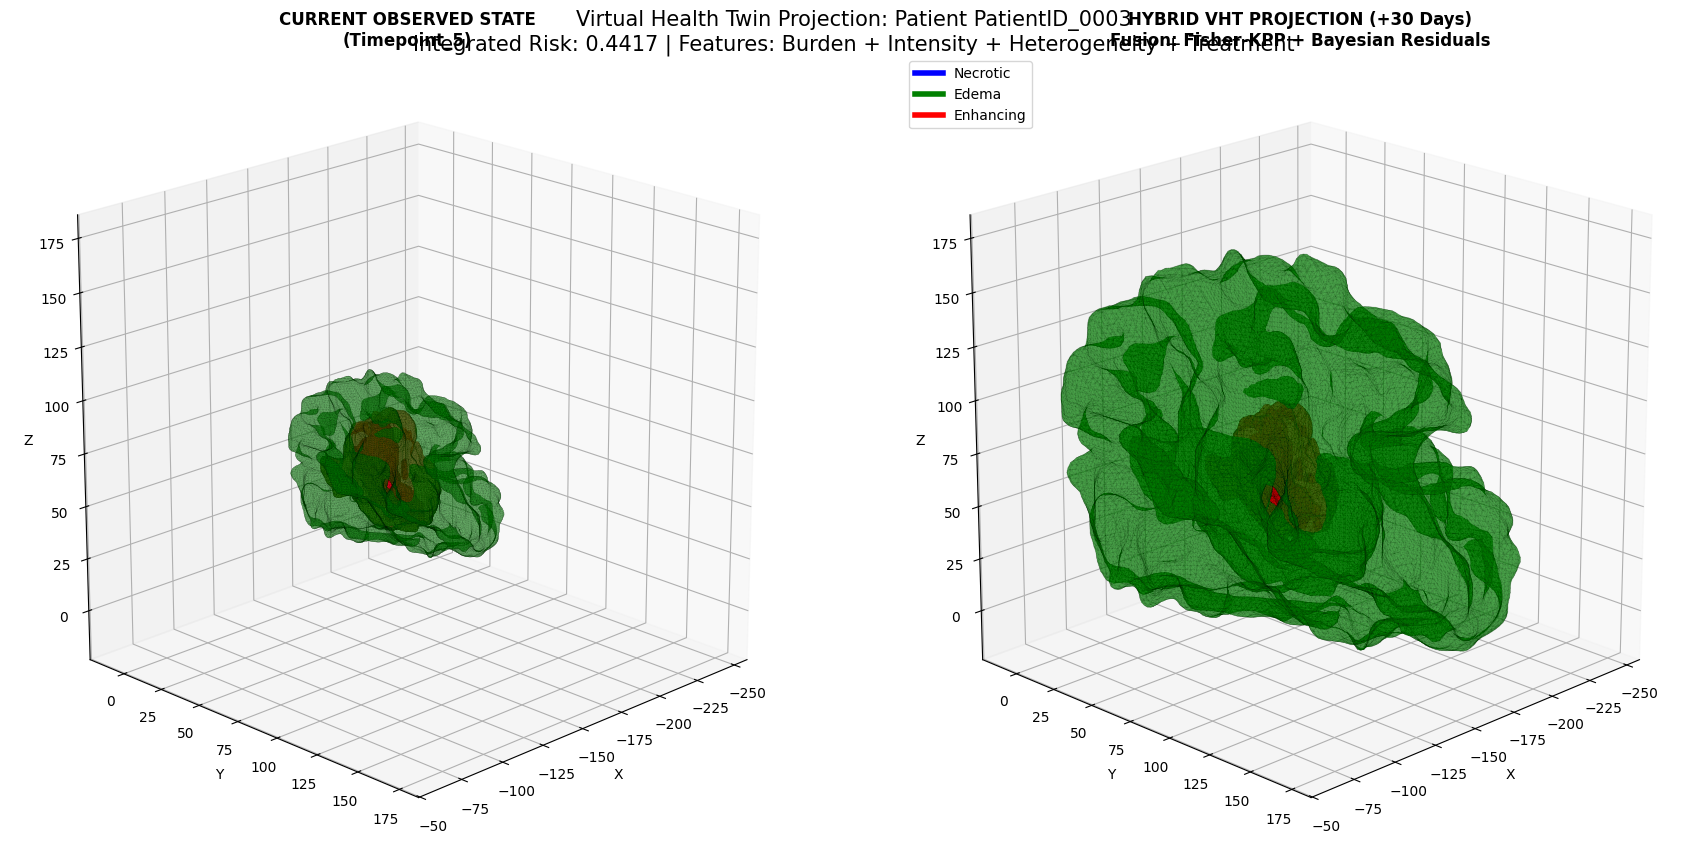

In [6]:
print("GP-only projection")
visualize_vht_3d_prediction(patient_idx=0, days=30, mode="gp")

Hybrid GP + CNF projection


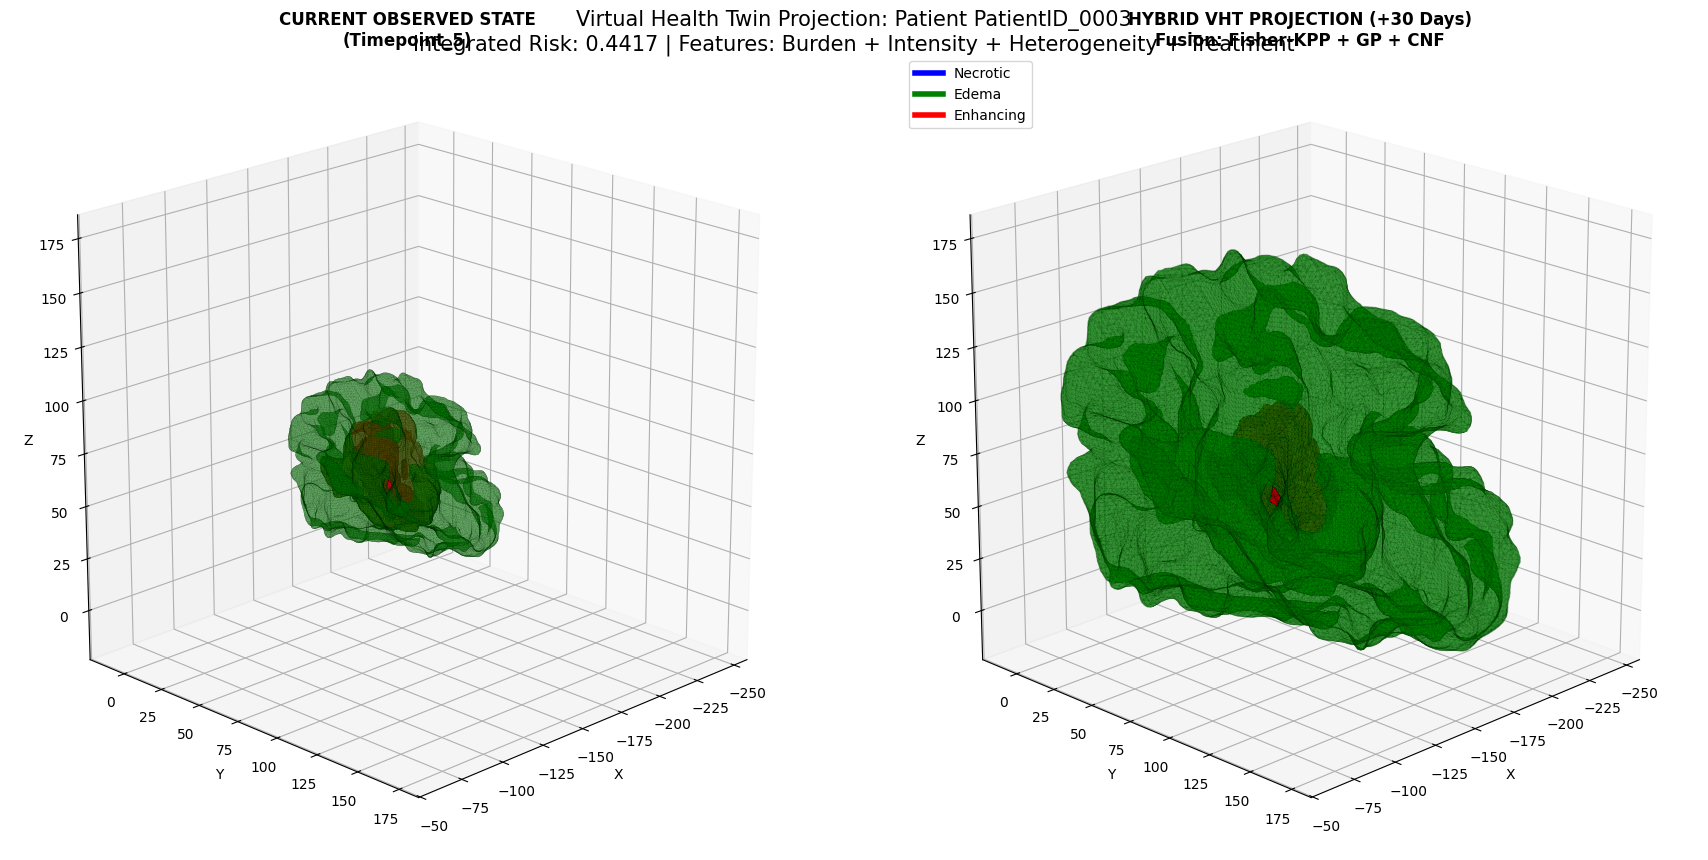

In [7]:
print("Hybrid GP + CNF projection")
visualize_vht_3d_prediction(patient_idx=0, days=30, mode="hybrid")

In [8]:
chemo_day=float(df_vht.iloc[0][' Number of days from Diagnosis to Initial Chemo Therapy Start date'])
print(f"Patient 1 Chemo Start Day: {chemo_day}")

Patient 1 Chemo Start Day: 26.0
